In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import shutil
import subprocess
import time

# ===== CẤU HÌNH =====
DRIVE_DIR = Path("/content/drive/MyDrive/[Q3-4] 2026/[S7] Computer Vision/CV-Nhóm 9/data")
LOCAL_ARCHIVE = Path("/content/archives")
LOCAL_DATA = Path("/content/dataset")

LOCAL_ARCHIVE.mkdir(parents=True, exist_ok=True)
LOCAL_DATA.mkdir(parents=True, exist_ok=True)

# ===== TÌM FILE NÉN =====
archives = sorted(DRIVE_DIR.glob("*.tar.gz"))

if not archives:
    raise FileNotFoundError(f"Không tìm thấy .tar.gz trong {DRIVE_DIR}")

print(f"Tìm thấy {len(archives)} file nén")

# ===== SAO CHÉP DRIVE -> COLAB =====
for i, src in enumerate(archives, 1):
    dst = LOCAL_ARCHIVE / src.name

    print(f"[{i}/{len(archives)}] Copy: {src.name}")
    start = time.time()

    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(src, dst)

    print(f"  Hoàn thành: {time.time() - start:.1f}s")

# ===== GIẢI NÉN TRÊN COLAB =====
for i, archive in enumerate(archives, 1):
    local_file = LOCAL_ARCHIVE / archive.name

    print(f"[{i}/{len(archives)}] Extract: {archive.name}")
    start = time.time()

    subprocess.run(
        ["tar", "-xzf", str(local_file), "-C", str(LOCAL_DATA)],
        check=True
    )

    print(f"  Hoàn thành: {time.time() - start:.1f}s")

print("\nDONE!")
print("Dataset:", LOCAL_DATA)

Tìm thấy 8 file nén
[1/8] Copy: can.tar.gz
  Hoàn thành: 65.1s
[2/8] Copy: fabric.tar.gz
  Hoàn thành: 296.1s
[3/8] Copy: fruit_jelly.tar.gz
  Hoàn thành: 37.5s
[4/8] Copy: rice.tar.gz
  Hoàn thành: 238.4s
[5/8] Copy: sheet_metal.tar.gz
  Hoàn thành: 55.9s
[6/8] Copy: vial.tar.gz
  Hoàn thành: 21.8s
[7/8] Copy: wallplugs.tar.gz
  Hoàn thành: 80.4s
[8/8] Copy: walnuts.tar.gz
  Hoàn thành: 179.6s
[1/8] Extract: can.tar.gz
  Hoàn thành: 36.3s
[2/8] Extract: fabric.tar.gz
  Hoàn thành: 149.1s
[3/8] Extract: fruit_jelly.tar.gz
  Hoàn thành: 20.6s
[4/8] Extract: rice.tar.gz
  Hoàn thành: 91.0s
[5/8] Extract: sheet_metal.tar.gz
  Hoàn thành: 23.9s
[6/8] Extract: vial.tar.gz
  Hoàn thành: 10.9s
[7/8] Extract: wallplugs.tar.gz
  Hoàn thành: 31.4s
[8/8] Extract: walnuts.tar.gz
  Hoàn thành: 95.4s

DONE!
Dataset: /content/dataset


In [3]:
!du -sh /content/archives
!du -sh /content/dataset
!df -h /content
!ls -lah /content/dataset | head -30

31G	/content/archives
31G	/content/dataset
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G  100G  127G  44% /
total 68K
drwxr-xr-x 10 root root    4.0K Oct 10 09:28 .
drwxr-xr-x  1 root root    4.0K Oct 10 09:04 ..
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 can
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 fabric
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 fruit_jelly
-rwxrwxrwx  1 2373 nogroup  21K Jul 18  2024 license.txt
-rwxrwxrwx  1 2373 nogroup  964 Mar 28  2025 readme.txt
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 rice
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 sheet_metal
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 vial
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 wallplugs
dr-xr-s---  7 2278     176 4.0K Jul 19  2024 walnuts


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path("/content/dataset")
OUT = Path("/content/defect_analysis")
OUT.mkdir(parents=True, exist_ok=True)

# Tự tìm các category có test_public hoặc test_pub
test_dirs = list(ROOT.rglob("test_public"))
test_dirs += list(ROOT.rglob("test_pub"))

categories = {}

for p in test_dirs:
    if (p / "bad").is_dir():
        categories[p.parent.name] = p

print(f"Tìm thấy {len(categories)} category:")

for category, path in sorted(categories.items()):
    print(f"  {category}: {path}")

if len(categories) != 8:
    print("CẢNH BÁO: Chưa tìm thấy đủ 8 category!")

Tìm thấy 8 category:
  can: /content/dataset/can/test_public
  fabric: /content/dataset/fabric/test_public
  fruit_jelly: /content/dataset/fruit_jelly/test_public
  rice: /content/dataset/rice/test_public
  sheet_metal: /content/dataset/sheet_metal/test_public
  vial: /content/dataset/vial/test_public
  wallplugs: /content/dataset/wallplugs/test_public
  walnuts: /content/dataset/walnuts/test_public


In [5]:
pairs = []

for category, test_dir in sorted(categories.items()):
    bad_dir = test_dir / "bad"
    gt_dir = test_dir / "ground_truth" / "bad"

    # Hỗ trợ trường hợp ground_truth nằm trong bad
    if not gt_dir.exists():
        gt_dir = bad_dir / "ground_truth"

    if not gt_dir.exists():
        raise FileNotFoundError(f"Thiếu ground truth: {category}")

    images = sorted(
        p for p in bad_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
    )

    for image_path in images:
        mask_path = gt_dir / f"{image_path.stem}_mask.png"

        if not mask_path.exists():
            raise FileNotFoundError(
                f"Không tìm thấy mask cho {image_path}"
            )

        pairs.append({
            "category": category,
            "image": image_path,
            "mask": mask_path
        })

pair_df = pd.DataFrame(pairs)

print("Tổng số ảnh lỗi:", len(pair_df))
display(
    pair_df.groupby("category")
    .size()
    .reset_index(name="n_bad_images")
)

Tổng số ảnh lỗi: 705


,category,n_bad_images
0,can,90
1,fabric,90
2,fruit_jelly,60
3,rice,90
4,sheet_metal,90
5,vial,105
6,wallplugs,90
7,walnuts,90


In [6]:
regions = []
images_info = []

for item in pairs:
    category = item["category"]
    image_path = item["image"]
    mask_path = item["mask"]

    with Image.open(image_path) as img:
        W, H = img.size

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None or mask.shape != (H, W):
        raise ValueError(f"Mask không hợp lệ: {mask_path}")

    binary = (mask > 0).astype(np.uint8)

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )

    images_info.append({
        "category": category,
        "image": image_path.name,
        "n_regions": n - 1,
        "total_area_pct": 100 * binary.mean()
    })

    for i in range(1, n):
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        regions.append({
            "category": category,
            "image": image_path.name,
            "region_id": i,
            "area_px": int(area),
            "area_pct": 100 * area / (W * H),
            "bbox_w_pct": 100 * w / W,
            "bbox_h_pct": 100 * h / H,
            "aspect_ratio": w / h,
            "fill_ratio": area / (w * h),
            "cx_norm": cx / W,
            "cy_norm": cy / H
        })

region_df = pd.DataFrame(regions)
image_df = pd.DataFrame(images_info)

region_df.to_csv(OUT / "defect_components.csv", index=False)
image_df.to_csv(OUT / "defect_images.csv", index=False)

print("Số vùng lỗi phân tích:", len(region_df))
display(region_df.head(10))

Số vùng lỗi phân tích: 1615


,category,image,region_id,area_px,area_pct,bbox_w_pct,bbox_h_pct,aspect_ratio,fill_ratio,cx_norm,cy_norm
0,can,000_overexposed.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
1,can,000_regular.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
2,can,000_shift_1.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
3,can,000_shift_2.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
4,can,000_shift_3.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
5,can,000_underexposed.png,1,60,0.002625,0.716846,0.585938,2.666667,0.625000,0.846602,0.197803
6,can,001_overexposed.png,1,250,0.010938,0.537634,7.910156,0.148148,0.257202,0.366756,0.851695
7,can,001_regular.png,1,250,0.010938,0.537634,7.910156,0.148148,0.257202,0.366756,0.851695
8,can,001_shift_1.png,1,250,0.010938,0.537634,7.910156,0.148148,0.257202,0.366756,0.851695
9,can,001_shift_2.png,1,250,0.010938,0.537634,7.910156,0.148148,0.257202,0.366756,0.851695


In [7]:
summary = []

for category in sorted(categories):
    r = region_df[region_df["category"] == category]
    im = image_df[image_df["category"] == category]

    row = {
        "category": category,
        "n_images": len(im),
        "n_regions": len(r),
        "regions_per_image": im["n_regions"].mean(),
    }

    for col in [
        "area_pct",
        "bbox_w_pct",
        "bbox_h_pct",
        "aspect_ratio",
        "fill_ratio"
    ]:
        for p in [10, 25, 50, 75, 90, 95]:
            row[f"{col}_p{p}"] = np.percentile(r[col], p)

    row["total_area_pct_p50"] = im["total_area_pct"].median()
    row["n_regions_p50"] = im["n_regions"].median()

    summary.append(row)

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    OUT / "summary_by_category.csv",
    index=False
)

display(
    summary_df[[
        "category",
        "n_images",
        "n_regions",
        "area_pct_p10",
        "area_pct_p25",
        "area_pct_p50",
        "area_pct_p75",
        "area_pct_p90",
        "area_pct_p95"
    ]].round(6)
)

,category,n_images,n_regions,area_pct_p10,area_pct_p25,area_pct_p50,area_pct_p75,area_pct_p90,area_pct_p95
0,can,90,96,0.001094,0.002855,0.005316,0.010413,0.017895,0.019689
1,fabric,90,192,0.000259,0.000758,0.003132,0.011334,0.022260,0.143333
2,fruit_jelly,60,228,0.002475,0.007769,0.021523,0.142450,1.607738,2.242592
3,rice,90,120,0.009446,0.050199,0.103730,0.158726,0.295781,0.984981
4,sheet_metal,90,450,0.007376,0.011725,0.019639,0.063423,0.096356,0.367668
5,vial,105,175,0.010526,0.054925,0.529398,1.066165,4.865940,9.659549
6,wallplugs,90,90,0.005605,0.025511,0.038456,0.309524,1.379075,1.473201
7,walnuts,90,264,0.011968,0.021312,0.110252,0.682382,2.429478,2.772332


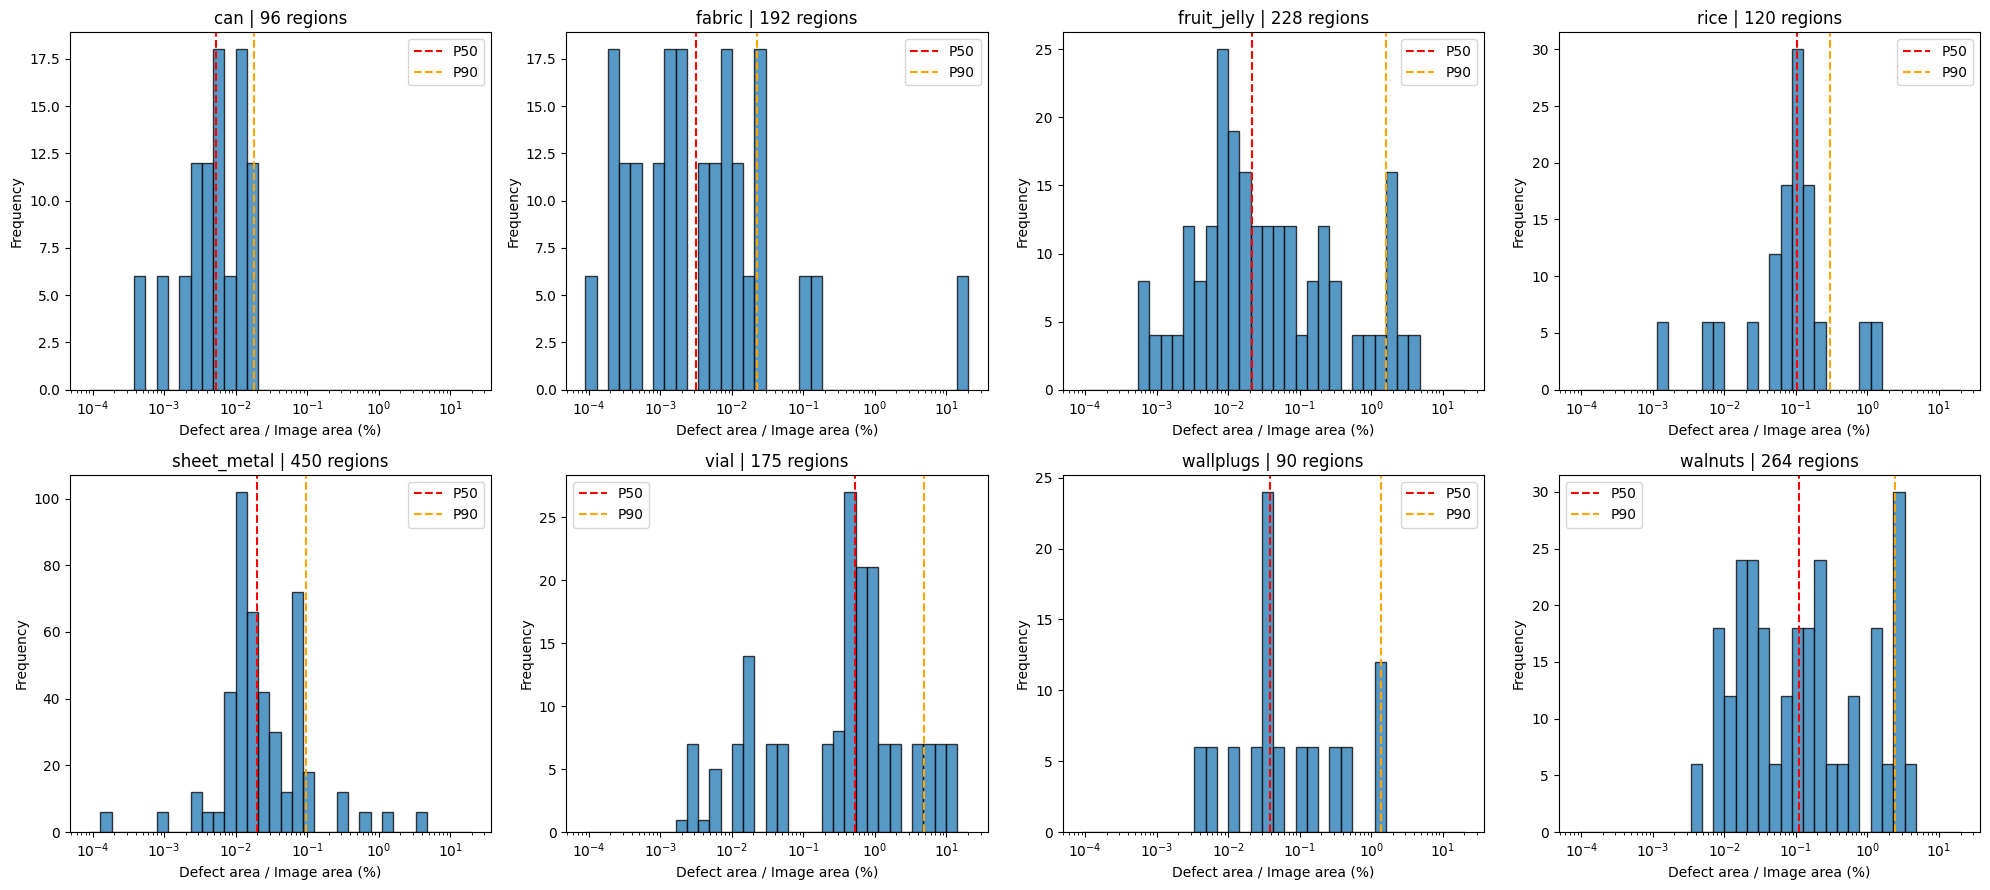

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

values = region_df["area_pct"].to_numpy()

bins = np.geomspace(
    values.min() * 0.9,
    values.max() * 1.1,
    35
)

for ax, category in zip(axes.flat, sorted(categories)):
    data = region_df.loc[
        region_df["category"] == category,
        "area_pct"
    ].to_numpy()

    ax.hist(data, bins=bins, edgecolor="black", alpha=0.75)

    p50 = np.median(data)
    p90 = np.percentile(data, 90)

    ax.axvline(p50, color="red", linestyle="--", label="P50")
    ax.axvline(p90, color="orange", linestyle="--", label="P90")

    ax.set_xscale("log")
    ax.set_title(f"{category} | {len(data)} regions")
    ax.set_xlabel("Defect area / Image area (%)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig(OUT / "region_area_histograms.png", dpi=200)
plt.show()

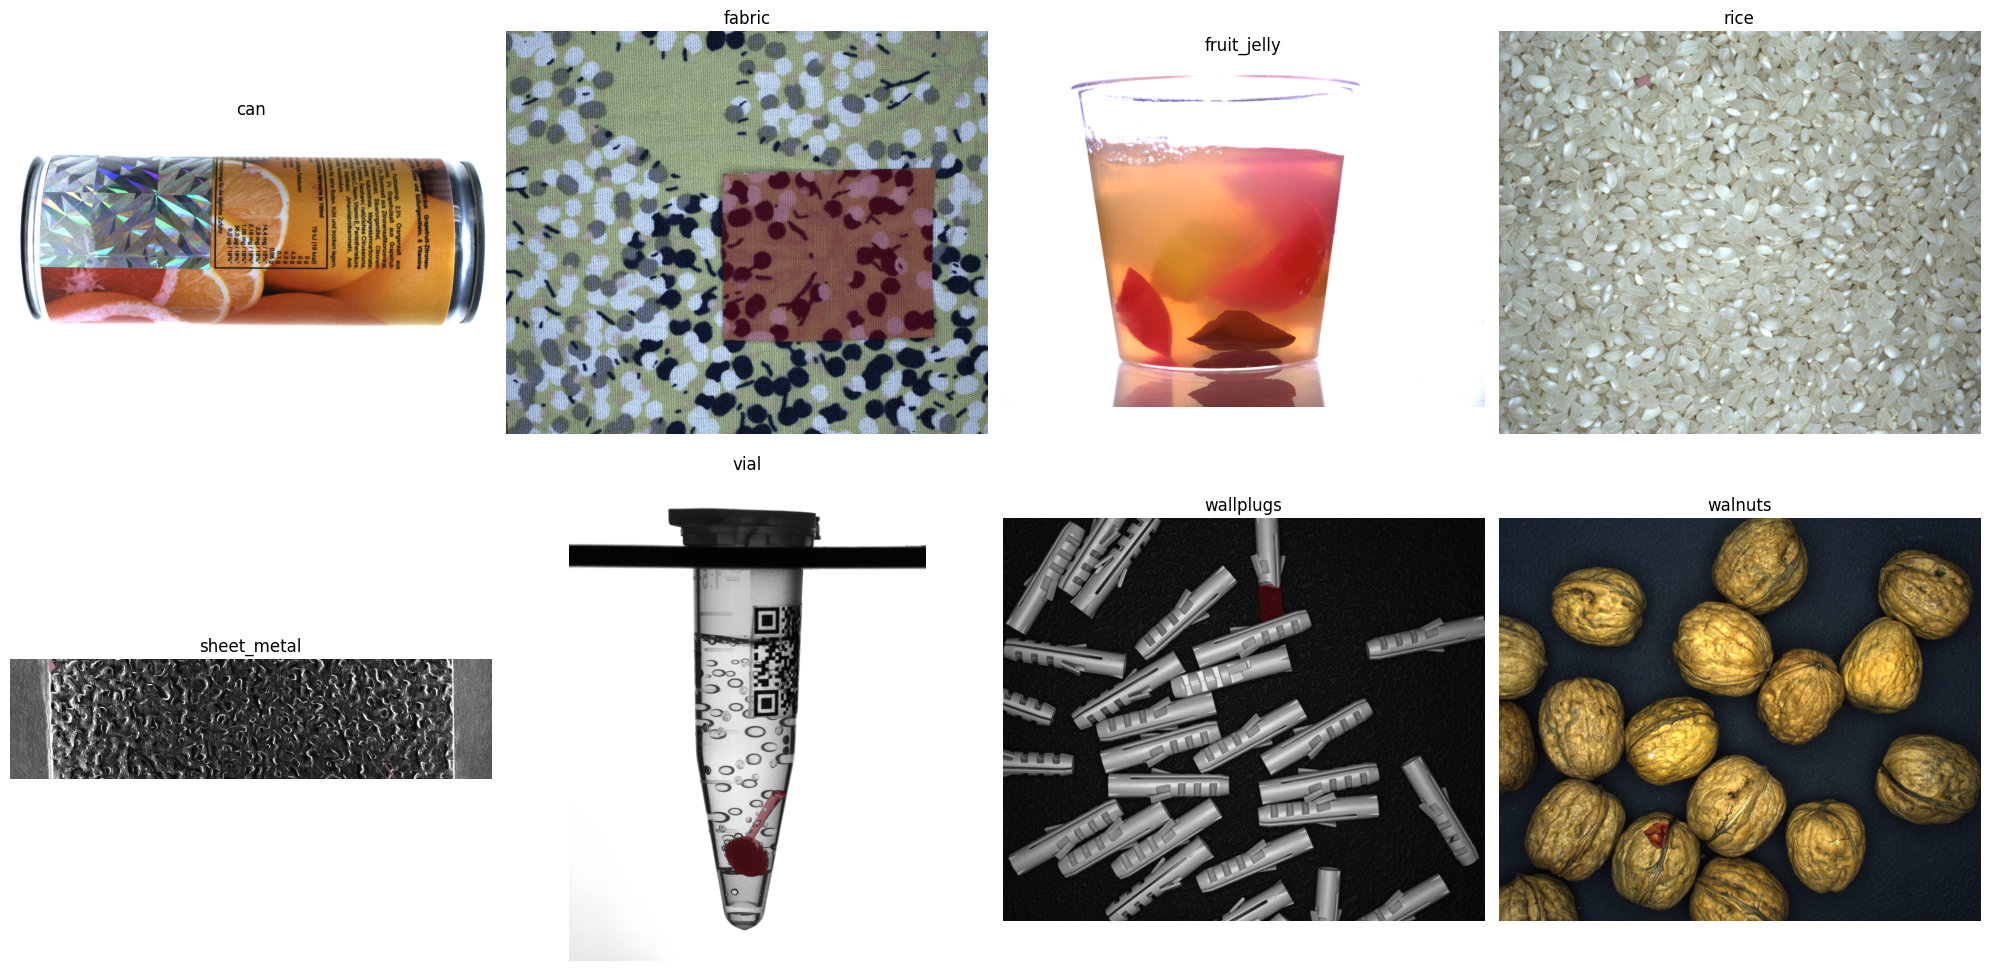

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, category in zip(axes.flat, sorted(categories)):
    item = pair_df[pair_df["category"] == category].iloc[0]

    image = np.array(Image.open(item["image"]).convert("RGB"))
    mask = cv2.imread(str(item["mask"]), 0) > 0

    ax.imshow(image)
    ax.imshow(
        np.ma.masked_where(~mask, mask),
        cmap="Reds",
        alpha=0.5,
        vmin=0,
        vmax=1
    )

    ax.set_title(category)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUT / "mask_overlays.png", dpi=180)
plt.show()

In [10]:
plans = []

for _, r in summary_df.iterrows():
    category = r["category"]

    for size, low, high in [
        ("small", 10, 25),
        ("medium", 25, 75),
        ("large", 75, 95)
    ]:
        plans.append({
            "category": category,
            "size": size,
            "area_min_pct": r[f"area_pct_p{low}"],
            "area_max_pct": r[f"area_pct_p{high}"],
            "bbox_w_p50": r["bbox_w_pct_p50"],
            "bbox_h_p50": r["bbox_h_pct_p50"],
            "aspect_ratio_p50": r["aspect_ratio_p50"],
            "fill_ratio_p50": r["fill_ratio_p50"],
            "regions_per_image": r["regions_per_image"]
        })

plan_df = pd.DataFrame(plans)

plan_df.to_csv(
    OUT / "synthetic_anomaly_plan.csv",
    index=False
)

display(plan_df.round(5))

,category,size,area_min_pct,area_max_pct,bbox_w_p50,bbox_h_p50,aspect_ratio_p50,fill_ratio_p50,regions_per_image
0,can,small,0.00109,0.00285,0.56004,1.31836,1.01613,0.67460,1.06667
1,can,medium,0.00285,0.01041,0.56004,1.31836,1.01613,0.67460,1.06667
2,can,large,0.01041,0.01969,0.56004,1.31836,1.01613,0.67460,1.06667
3,fabric,small,0.00026,0.00076,0.79657,0.95215,1.18333,0.58490,2.13333
4,fabric,medium,0.00076,0.01133,0.79657,0.95215,1.18333,0.58490,2.13333
5,fabric,large,0.01133,0.14333,0.79657,0.95215,1.18333,0.58490,2.13333
6,fruit_jelly,small,0.00247,0.00777,3.90476,3.02632,2.02564,0.54907,3.80000
7,fruit_jelly,medium,0.00777,0.14245,3.90476,3.02632,2.02564,0.54907,3.80000
8,fruit_jelly,large,0.14245,2.24259,3.90476,3.02632,2.02564,0.54907,3.80000
9,rice,small,0.00945,0.05020,3.08415,3.90625,0.95826,0.68622,1.33333
